In [2]:
import pandas as pd
import numpy as np 
from keras.models import Sequential
from keras import layers, ops 
import keras
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tf2onnx
import os
import subprocess
import sys 

In [3]:
X = np.load("../Data/X_train.npy")
Y = np.load("../Data/Y_train.npy")

print(X.shape)
print(Y.shape)

(20631, 14)
(20631,)


In [4]:
def AutoEncoder(X, input_dim, latent_dim, output_dim):
    model = Sequential([
        # Encoding phase
        keras.Input((input_dim, )),
        layers.Dense(16, name = 'Enc_layer1', kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(8, name = 'Enc_layer2', kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(latent_dim, name = 'Latent_Space', kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)), 
        layers.LeakyReLU(alpha = 0.01), 

        #Decoding phase
        layers.Dense(8, name = "dec_dense1", kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(16, name = "dec_dense2", kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(output_dim, name="output_layer", kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1))
    ])
    # model.summary()
    return model

In [5]:
def train(X, epochs, batch_size): 
    input_dim = X.shape[1]
    latent_dim = 4
    output_dim = X.shape[1]
    model = AutoEncoder(X, input_dim, latent_dim, output_dim)

    model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.0005), loss = 'mse')

    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    model.fit(X, 
              X,
              epochs = epochs,
              batch_size = batch_size,
              verbose = 1,
              shuffle = True,
              callbacks = [early_stop]
             )

    X_decoded = model.predict(X)

    return X_decoded, model
    

In [6]:
X_decoded, model = train(X, epochs=100, batch_size=256)

Epoch 1/100


/Users/shivaram/telemetry-anomaly-detector/.venv/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 458us/step - loss: 13.9436 
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 11.9822
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 10.3858
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - loss: 9.0210
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - loss: 7.8423
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 6.8212
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - loss: 5.9349
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 5.1647
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 4.4947
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 3.9118
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 3.4045
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - loss: 2.9629
Epoch 13/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - loss: 2.5785
Epoch 14/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 2.2437
Epoch 15/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/st

645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 168us/step


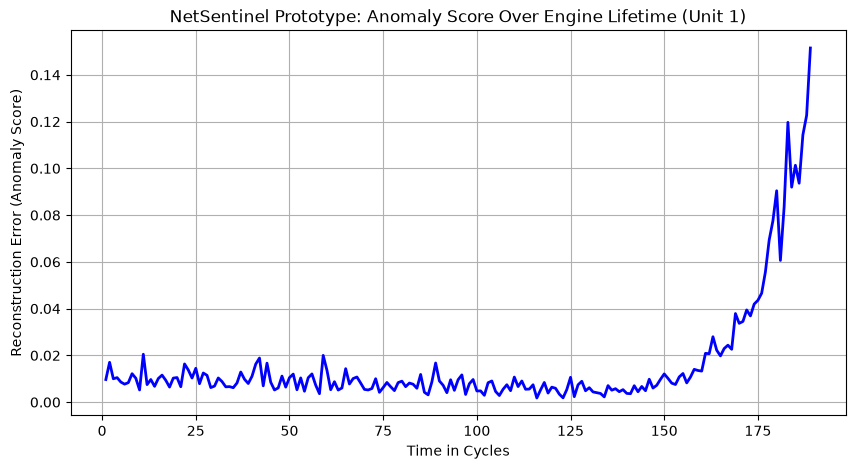

In [7]:
X_pred = model.predict(X)
reconstruction_errors = np.mean(np.square(X - X_pred), axis=1)

metadata = pd.read_csv('../Data/metadata.csv')

metadata['anomaly_score'] = reconstruction_errors

engine_1 = metadata[metadata['unit_number'] == 4].sort_values('time_in_cycles')

plt.figure(figsize=(10, 5))
plt.plot(engine_1['time_in_cycles'], engine_1['anomaly_score'], color='blue', linewidth=2)
plt.title("NetSentinel Prototype: Anomaly Score Over Engine Lifetime (Unit 1)")
plt.xlabel("Time in Cycles")
plt.ylabel("Reconstruction Error (Anomaly Score)")
plt.grid(True)
plt.show()

In [8]:
unit_data = metadata[metadata['unit_number'] == 1]
unit_data

,unit_number,time_in_cycles,anomaly_score
0,1,1,0.016292
1,1,2,0.011708
2,1,3,0.016176
3,1,4,0.025383
4,1,5,0.010606
...,...,...,...
187,1,188,0.075446
188,1,189,0.086337
189,1,190,0.092276
190,1,191,0.074421


In [9]:
error = unit_data['anomaly_score']
error

0      0.016292
1      0.011708
2      0.016176
3      0.025383
4      0.010606
         ...   
187    0.075446
188    0.086337
189    0.092276
190    0.074421
191    0.089714
Name: anomaly_score, Length: 192, dtype: float64

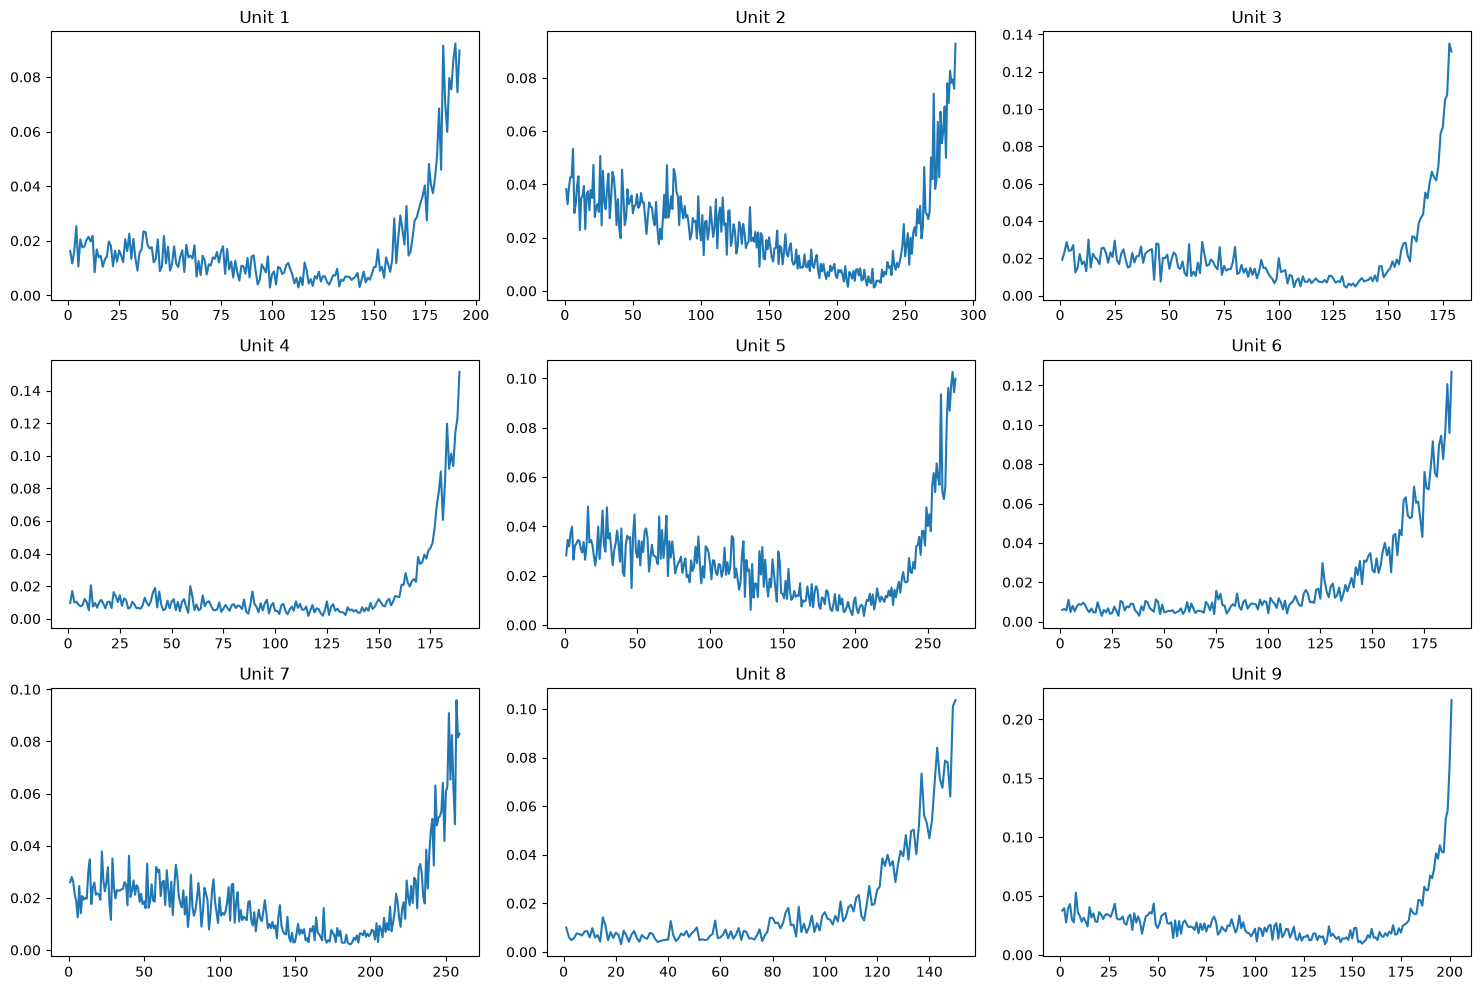

In [10]:
df = pd.read_csv("../Data/dataset.csv")
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for idx, unit in enumerate(df['unit_number'].unique()[:9]):
    ax = axes[idx//3, idx%3]
    unit_data = metadata[metadata['unit_number'] == unit]
    errors_for_unit = unit_data['anomaly_score']
    ax.plot(unit_data['time_in_cycles'], errors_for_unit)
    ax.set_title(f'Unit {unit}')
plt.tight_layout()

In [11]:
model.save("../Model/AutoEncoder.keras")
print("Model saved sucessfully!")

Model saved sucessfully!


In [12]:
if not os.path.exists('../Model/model/tf_saved_model'):
    model.export('../Model/model/tf_saved_model')
    print("SavedModel artifact generated.")
else:
    print("Found existing SavedModel artifact from your last run. Perfect.")

# sys.executable forces the script to use the precise .venv Python 3.11 interpreter where tf2onnx lives
onnx_command = f"{sys.executable} -m tf2onnx.convert --saved-model ../Model/model/tf_saved_model --output ../Model/model/telemetry_autoencoder.onnx --opset 15"

# Run the terminal command safely
result = subprocess.run(onnx_command.split(), capture_output=True, text=True)

# 3. Verify the final result
if result.returncode == 0:
    print("\nSUCCESS! ")
else:
    print("\n Error ")
    print(result.stderr)

Found existing SavedModel artifact from your last run. Perfect.

SUCCESS! 


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Enc_layer1 (Dense)              │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Enc_layer2 (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense1 (Dense)              │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense2 (Dense)              │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 14)             │           238 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,504 (9.79 KB)

 Trainable params: 834 (3.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,670 (6.53 KB)